In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Create the dataset
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Henry',
             'Ivy', 'Jack', 'Karen', 'Leo', 'Mia', 'Noah', 'Olivia', 'Peter',
             'Quinn', 'Rachel', 'Sam', 'Tina'],
    'age': [25, 32, 28, 45, 35, 29, 41, 26, 38, 33, 47, 24, 31, 42, 27, 36, 44, 30, 23, 39],
    'income': [45000, 62000, 51000, 78000, 69000, 48000, 72000, 43000, 65000,
               58000, 81000, 39000, 56000, 74000, 46000, 67000, 76000, 54000, 38000, 70000]
}

df = pd.DataFrame(data)
print("Dataset created successfully!")
print(f"Shape: {df.shape}")
df.head(10)

Dataset created successfully!
Shape: (20, 3)


,name,age,income
0,Alice,25,45000
1,Bob,32,62000
2,Charlie,28,51000
3,David,45,78000
4,Eva,35,69000
5,Frank,29,48000
6,Grace,41,72000
7,Henry,26,43000
8,Ivy,38,65000
9,Jack,33,58000


In [ ]:
# Display basic information
print("="*50)
print("DATASET INFORMATION")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("CHECK FOR MISSING VALUES")
print("="*50)
print(df.isnull().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    20 non-null     object
 1   age     20 non-null     int64 
 2   income  20 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 612.0+ bytes
None

STATISTICAL SUMMARY
             age       income
count  20.000000     20.00000
mean   33.750000  59600.00000
std     7.447182  13635.86602
min    23.000000  38000.00000
25%    27.750000  47500.00000
50%    32.500000  60000.00000
75%    39.500000  70500.00000
max    47.000000  81000.00000

CHECK FOR MISSING VALUES
name      0
age       0
income    0
dtype: int64


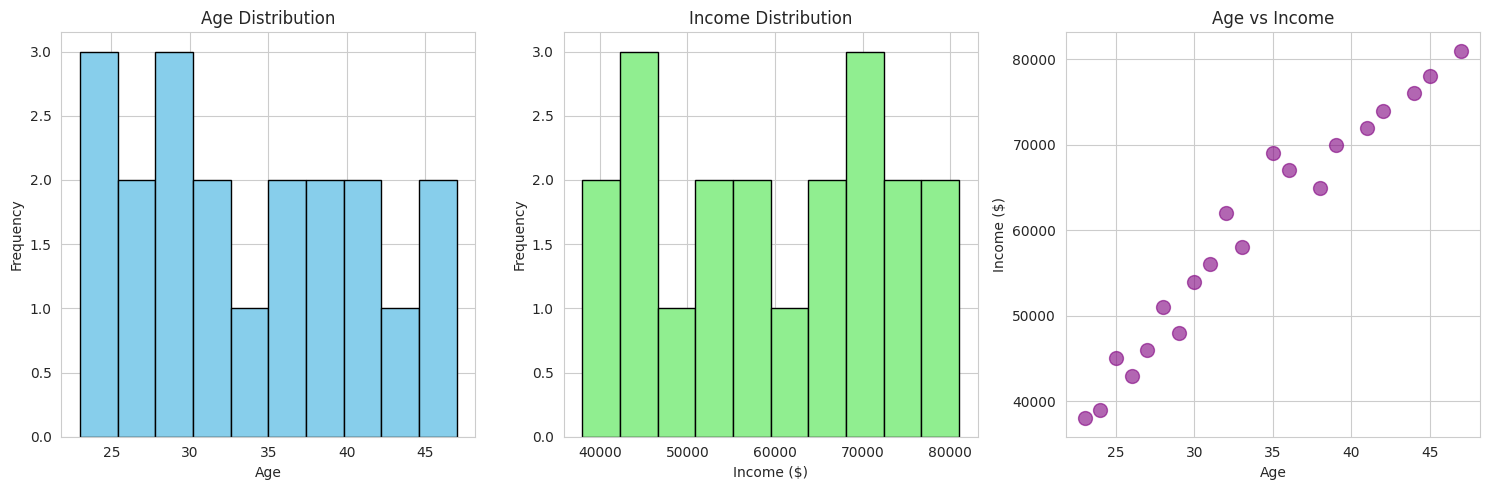

In [ ]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age distribution
axes[0].hist(df['age'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Income distribution
axes[1].hist(df['income'], bins=10, color='lightgreen', edgecolor='black')
axes[1].set_title('Income Distribution')
axes[1].set_xlabel('Income ($)')
axes[1].set_ylabel('Frequency')

# Scatter plot: Age vs Income
axes[2].scatter(df['age'], df['income'], alpha=0.6, s=100, color='purple')
axes[2].set_title('Age vs Income')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Income ($)')

plt.tight_layout()
plt.show()

In [ ]:
# Select features for clustering
X = df[['age', 'income']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the results
print("Original features (first 5 rows):")
print(X[:5])

print("\nScaled features (first 5 rows):")
print(X_scaled[:5])

print(f"\nMean of scaled features: {X_scaled.mean(axis=0)}")
print(f"Standard deviation of scaled features: {X_scaled.std(axis=0)}")

Original features (first 5 rows):
[[   25 45000]
 [   32 62000]
 [   28 51000]
 [   45 78000]
 [   35 69000]]

Scaled features (first 5 rows):
[[-1.20546403 -1.09852091]
 [-0.24109281  0.18057878]
 [-0.79216208 -0.64707396]
 [ 1.54988233  1.38443731]
 [ 0.17220915  0.70726689]]

Mean of scaled features: [ 1.11022302e-17 -5.55111512e-18]
Standard deviation of scaled features: [1. 1.]


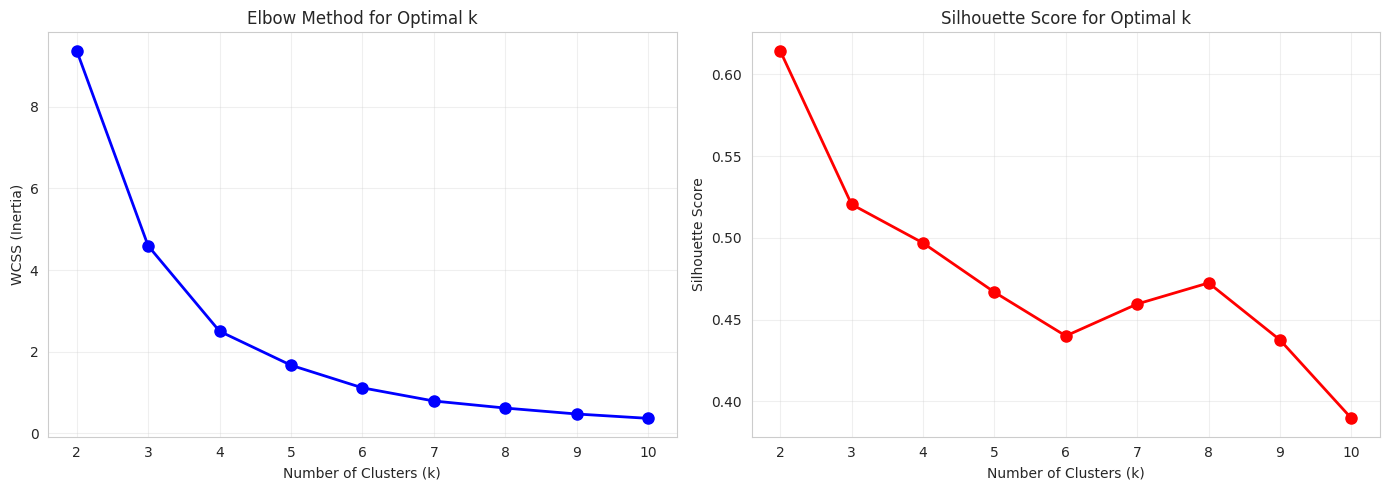

WCSS values:
k=2: 9.38
k=3: 4.59
k=4: 2.50
k=5: 1.67
k=6: 1.11
k=7: 0.79
k=8: 0.62
k=9: 0.47
k=10: 0.36

Silhouette Scores:
k=2: 0.6144
k=3: 0.5205
k=4: 0.4969
k=5: 0.4668
k=6: 0.4401
k=7: 0.4596
k=8: 0.4725
k=9: 0.4376
k=10: 0.3897


In [ ]:
# Calculate WCSS (Within-Cluster Sum of Squares) for different k values
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot the elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

# Silhouette Score
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display the values
print("WCSS values:")
for k, w in zip(K_range, wcss):
    print(f"k={k}: {w:.2f}")

print("\nSilhouette Scores:")
for k, s in zip(K_range, silhouette_scores):
    print(f"k={k}: {s:.4f}")

In [ ]:
# Choose optimal k (let's say k=3 based on elbow method)
optimal_k = 3

# Apply K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Get cluster centers in original scale
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Display results
print(f"Clustering with k={optimal_k}")
print("\nClustered Data:")
print(df)

print("\nCluster Centers (Original Scale):")
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}: Age={center[0]:.1f}, Income=${center[1]:.0f}")

Clustering with k=3

Clustered Data:
       name  age  income  cluster
0     Alice   25   45000        0
1       Bob   32   62000        2
2   Charlie   28   51000        0
3     David   45   78000        1
4       Eva   35   69000        2
5     Frank   29   48000        0
6     Grace   41   72000        1
7     Henry   26   43000        0
8       Ivy   38   65000        2
9      Jack   33   58000        2
10    Karen   47   81000        1
11      Leo   24   39000        0
12      Mia   31   56000        2
13     Noah   42   74000        1
14   Olivia   27   46000        0
15    Peter   36   67000        2
16    Quinn   44   76000        1
17   Rachel   30   54000        2
18      Sam   23   38000        0
19     Tina   39   70000        1

Cluster Centers (Original Scale):
Cluster 0: Age=26.0, Income=$44286
Cluster 1: Age=43.0, Income=$75167
Cluster 2: Age=33.6, Income=$61571


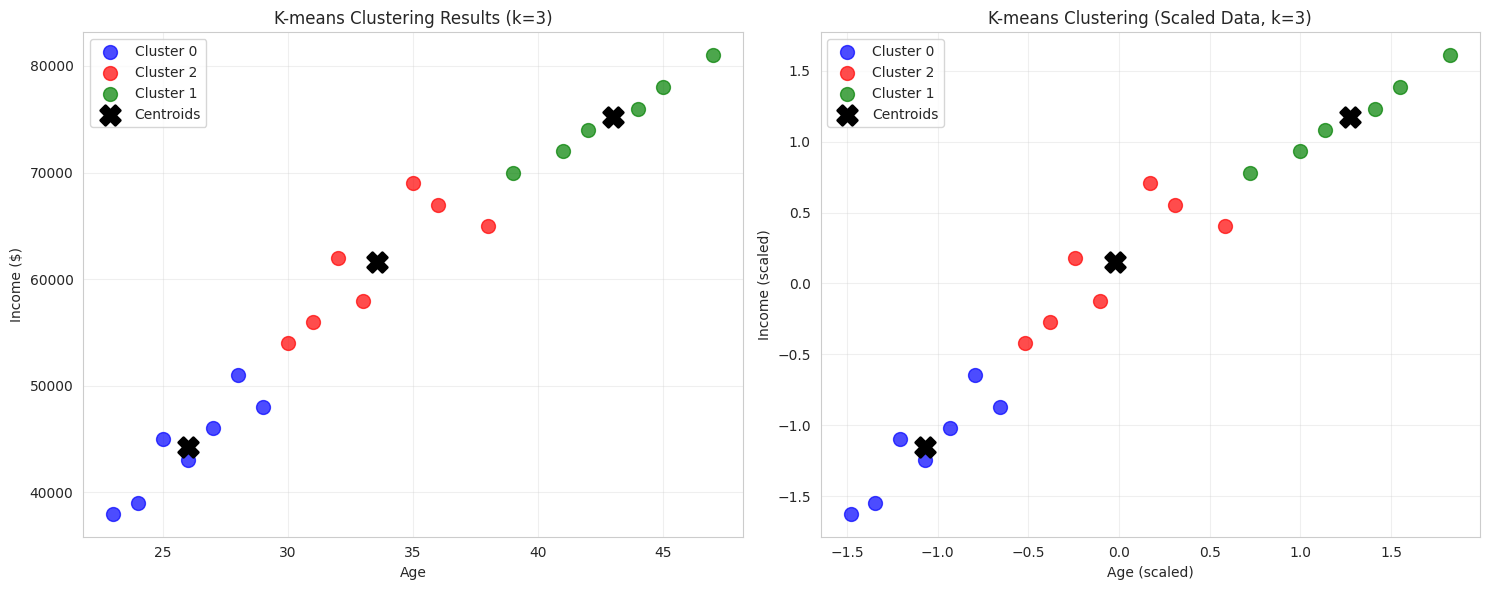

In [ ]:
# Create visualization of clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot with clusters (Original Scale)
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
for cluster in df['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster]
    ax1.scatter(cluster_data['age'], cluster_data['income'],
               c=colors[cluster], label=f'Cluster {cluster}', s=100, alpha=0.7)

# Plot centroids
ax1.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           color='black', marker='X', s=200, linewidth=2, label='Centroids')
ax1.set_xlabel('Age')
ax1.set_ylabel('Income ($)')
ax1.set_title(f'K-means Clustering Results (k={optimal_k})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scatter plot with clusters (Scaled Data)
for cluster in df['cluster'].unique():
    cluster_data_scaled = X_scaled[df['cluster'] == cluster]
    ax2.scatter(cluster_data_scaled[:, 0], cluster_data_scaled[:, 1],
               c=colors[cluster], label=f'Cluster {cluster}', s=100, alpha=0.7)

# Plot centroids on scaled data
ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           color='black', marker='X', s=200, linewidth=2, label='Centroids')
ax2.set_xlabel('Age (scaled)')
ax2.set_ylabel('Income (scaled)')
ax2.set_title(f'K-means Clustering (Scaled Data, k={optimal_k})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Analyze each cluster
for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    print("="*50)
    print(f"CLUSTER {cluster} ANALYSIS")
    print("="*50)
    print(f"Number of customers: {len(cluster_data)}")
    print(f"\nAge range: {cluster_data['age'].min()} - {cluster_data['age'].max()}")
    print(f"Average age: {cluster_data['age'].mean():.1f}")
    print(f"Income range: ${cluster_data['income'].min():,} - ${cluster_data['income'].max():,}")
    print(f"Average income: ${cluster_data['income'].mean():,.0f}")
    print("\nCustomers in this cluster:")
    print(cluster_data[['name', 'age', 'income']].to_string(index=False))
    print("\n")

CLUSTER 0 ANALYSIS
Number of customers: 7

Age range: 23 - 29
Average age: 26.0
Income range: $38,000 - $51,000
Average income: $44,286

Customers in this cluster:
   name  age  income
  Alice   25   45000
Charlie   28   51000
  Frank   29   48000
  Henry   26   43000
    Leo   24   39000
 Olivia   27   46000
    Sam   23   38000


CLUSTER 1 ANALYSIS
Number of customers: 6

Age range: 39 - 47
Average age: 43.0
Income range: $70,000 - $81,000
Average income: $75,167

Customers in this cluster:
 name  age  income
David   45   78000
Grace   41   72000
Karen   47   81000
 Noah   42   74000
Quinn   44   76000
 Tina   39   70000


CLUSTER 2 ANALYSIS
Number of customers: 7

Age range: 30 - 38
Average age: 33.6
Income range: $54,000 - $69,000
Average income: $61,571

Customers in this cluster:
  name  age  income
   Bob   32   62000
   Eva   35   69000
   Ivy   38   65000
  Jack   33   58000
   Mia   31   56000
 Peter   36   67000
Rachel   30   54000




In [ ]:
# Create a summary table for cluster profiling
cluster_summary = df.groupby('cluster').agg({
    'age': ['count', 'mean', 'min', 'max'],
    'income': ['mean', 'min', 'max']
}).round(2)

# Rename columns for better readability
cluster_summary.columns = ['Count', 'Avg Age', 'Min Age', 'Max Age',
                          'Avg Income', 'Min Income', 'Max Income']

print("CLUSTER PROFILING SUMMARY")
print("="*60)
print(cluster_summary)

# Add cluster labels based on characteristics
def label_cluster(row):
    avg_age = row['Avg Age']
    avg_income = row['Avg Income']
    if avg_age < 30:
        return "Young Professionals"
    elif avg_age < 40:
        return "Mid-Career"
    else:
        return "Senior Executives"

cluster_summary['Segment'] = cluster_summary.apply(label_cluster, axis=1)
print("\n" + "="*60)
print("CLUSTER SEGMENTATION")
print("="*60)
print(cluster_summary[['Count', 'Avg Age', 'Avg Income', 'Segment']])

CLUSTER PROFILING SUMMARY
         Count  Avg Age  Min Age  Max Age  Avg Income  Min Income  Max Income
cluster                                                                      
0            7    26.00       23       29    44285.71       38000       51000
1            6    43.00       39       47    75166.67       70000       81000
2            7    33.57       30       38    61571.43       54000       69000

CLUSTER SEGMENTATION
         Count  Avg Age  Avg Income              Segment
cluster                                                 
0            7    26.00    44285.71  Young Professionals
1            6    43.00    75166.67    Senior Executives
2            7    33.57    61571.43           Mid-Career


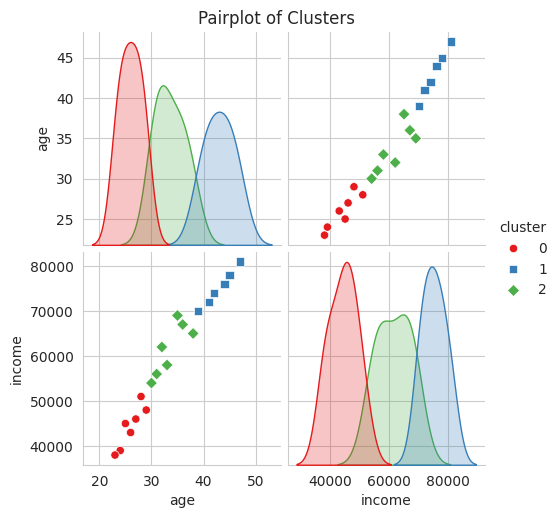

In [ ]:
# Create pairplot to see relationships
sns.pairplot(df, hue='cluster', vars=['age', 'income'],
             palette='Set1', diag_kind='kde', markers=["o", "s", "D"])
plt.suptitle('Pairplot of Clusters', y=1.02)
plt.show()

In [ ]:
# Calculate clustering metrics
silhouette_avg = silhouette_score(X_scaled, df['cluster'])

# Calculate inertia
inertia = kmeans.inertia_

# Calculate cluster sizes
cluster_sizes = df['cluster'].value_counts().sort_index()

print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_avg:.4f}")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"Cluster sizes: {dict(cluster_sizes)}")

# Silhouette score interpretation
if silhouette_avg > 0.5:
    interpretation = "Good clustering structure"
elif silhouette_avg > 0.3:
    interpretation = "Moderate clustering structure"
else:
    interpretation = "Weak clustering structure"
print(f"\nInterpretation: {interpretation}")

MODEL EVALUATION METRICS
Number of clusters: 3
Silhouette Score: 0.5205
Inertia (WCSS): 4.59
Cluster sizes: {0: np.int64(7), 1: np.int64(6), 2: np.int64(7)}

Interpretation: Good clustering structure


In [ ]:
# Save the clustered dataset
df.to_csv('kmeans_clustered_data.csv', index=False)
print("Clustered data saved to 'kmeans_clustered_data.csv'")

# Display final dataset
print("\nFINAL CLUSTERED DATASET")
print("="*50)
df

Clustered data saved to 'kmeans_clustered_data.csv'

FINAL CLUSTERED DATASET


,name,age,income,cluster
0,Alice,25,45000,0
1,Bob,32,62000,2
2,Charlie,28,51000,0
3,David,45,78000,1
4,Eva,35,69000,2
5,Frank,29,48000,0
6,Grace,41,72000,1
7,Henry,26,43000,0
8,Ivy,38,65000,2
9,Jack,33,58000,2


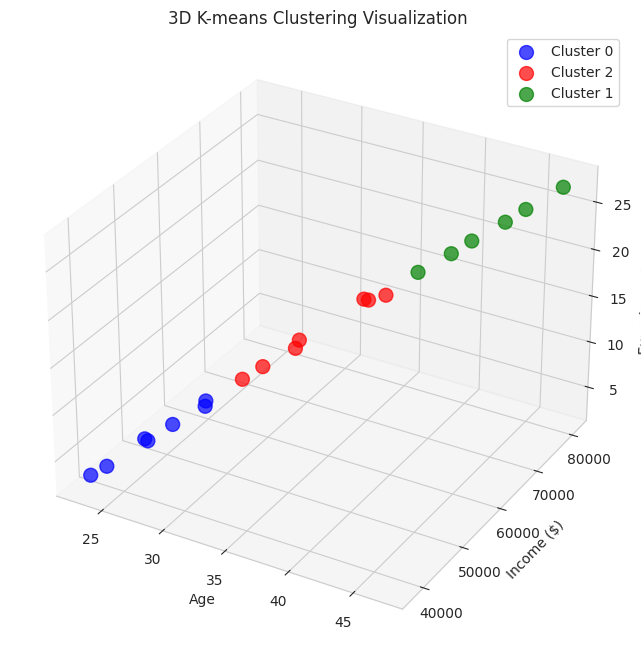

In [ ]:
# Create a 3D visualization if we add a third feature
from mpl_toolkits.mplot3d import Axes3D

# For demonstration, let's create a 3D plot using age, income, and a generated feature
df['experience'] = df['age'] - 20  # approximate years of experience

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in df['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster]
    ax.scatter(cluster_data['age'], cluster_data['income'], cluster_data['experience'],
               c=colors[cluster], label=f'Cluster {cluster}', s=100, alpha=0.7)

ax.set_xlabel('Age')
ax.set_ylabel('Income ($)')
ax.set_zlabel('Experience (years)')
ax.set_title('3D K-means Clustering Visualization')
ax.legend()
plt.show()